In [13]:
import os
import csv
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.interpolate import splrep, splev
from statsmodels.nonparametric.smoothers_lowess import lowess


# ============================================================
# Basic processing functions
# ============================================================

def interplote_data(data, num):
    """
    Interpolate a one-dimensional trace to a fixed number of points.

    Function name is intentionally preserved for compatibility
    with the original code.
    """
    x = np.linspace(0, 1, len(data))
    spl = splrep(x, data)
    new_x = np.linspace(0, 1, num)
    new_value = splev(new_x, spl)

    return new_value


def lowess_smooth(data):
    """
    Smooth a one-dimensional trace using LOWESS.
    """
    x = np.linspace(0, 1, len(data))
    y = data

    frac = 0.05  # IMPORTANT: original window length
    lowess_result = lowess(y, x, frac=frac)

    return lowess_result[:, 1]


def find_baseline(data):
    """
    Identify the minimum in the middle 40% of the trace and calculate
    the local average around that minimum.

    Original calculation is preserved.
    """
    n = len(data)

    start_index = int(n * 0.30)
    end_index = int(n * 0.70)

    middle_40_percent = data[start_index:end_index]

    min_value = min(middle_40_percent)

    min_indices_relative = [
        i
        for i, value in enumerate(middle_40_percent)
        if value == min_value
    ]

    min_indices_absolute = start_index + min_indices_relative[0]

    baseline_value = data[
        min_indices_absolute - int(n * 0.005):
        min_indices_absolute + int(n * 0.005)
    ]

    baseline_average = np.mean(baseline_value)

    return baseline_average


def find_crops(data, target_value):
    """
    ORIGINAL CROP FUNCTION.

    The calculation and control flow below are intentionally preserved
    so that previously processed and newly processed data remain
    directly comparable.
    """
    data_as_int = [int(float(x)) for x in data]
    matching_indices = [
        i
        for i, value in enumerate(data_as_int)
        if value < target_value
    ]

    mini_crop = 0
    max_crop = len(data)

    if 0 in matching_indices:
        i = 0

        while i in range(0, len(matching_indices)):
            if 0 < (
                matching_indices[i + 1] - matching_indices[i]
            ) <= 2:
                mini_crop = matching_indices[i + 1]
                i += 1
            else:
                break

    reverse_matching_indices = matching_indices[::-1]

    if (len(data) - 1) in reverse_matching_indices:
        i = 0

        while i in range(0, len(reverse_matching_indices)):
            if 0 < (
                reverse_matching_indices[i]
                - reverse_matching_indices[i + 1]
            ) <= 2:
                max_crop = reverse_matching_indices[i + 1]
                i += 1
            else:
                break

    return mini_crop, max_crop


def adjust_the_line(red_cell, green_cell):
    """
    Interpolate, smooth, crop, and re-interpolate paired traces.

    Cropping is determined from the first input channel and applied
    identically to the second input channel.

    Original input/output behavior is preserved.
    """

    # First channel
    new_red_value = interplote_data(red_cell, 1000)
    average = lowess_smooth(new_red_value)

    baseline_average = find_baseline(average)
    mini_crop, max_crop = find_crops(
        average,
        baseline_average
    )

    data_new = average[mini_crop:max_crop]

    x = np.linspace(0, 1, len(data_new))
    y = data_new

    spl = splrep(x, y)
    new_x = np.linspace(x.min(), x.max(), 1000)
    new_red_y = splev(new_x, spl)

    # Second channel
    new_green_value = interplote_data(green_cell, 1000)
    smooth_green = lowess_smooth(new_green_value)

    data_new_green = smooth_green[mini_crop:max_crop]

    x = np.linspace(0, 1, len(data_new_green))
    y = data_new_green

    spl = splrep(x, y)
    new_x = np.linspace(x.min(), x.max(), 1000)
    new_green_y = splev(new_x, spl)

    return new_red_y, new_green_y


def normalize_data(data):
    """
    Normalize a trace to its maximum value.
    """
    data_max = max(data)

    normalized_data_1d = [
        value / data_max
        for value in data
    ]

    return normalized_data_1d


def interpolate_data_b(x, y, num):
    """
    Interpolate y as a function of x.
    """
    spl = splrep(x, y)
    new_x = np.linspace(min(x), max(x), num)
    new_value = splev(new_x, spl)

    return new_value


def half_data(data, num):
    """
    Divide the trace into two halves and reverse the first half.

    Original calculation is preserved.
    """
    num_r = math.ceil(num / 2)

    front_half = data[:num_r]
    back_half = data[num_r:]

    front_half_reversed = front_half[::-1]

    return front_half_reversed, back_half


def ave_center_data(data):
    """
    Calculate the original central baseline.
    """
    n = len(data)

    start = int(n * 0.495)
    end = int(n * 0.595)

    middle_region = data[start:end]

    baseline = sum(middle_region) / len(middle_region)

    return baseline


def fraction(data):
    """
    Calculate the cumulative fraction of the trace integral.
    """
    total_sum = sum(data)

    cumulative_sum = []
    current_sum = 0

    for value in data:
        current_sum += value
        cumulative_sum.append(current_sum)

    cumulative_weights = [
        current_value / total_sum
        for current_value in cumulative_sum
    ]

    return cumulative_weights


# ============================================================
# Figure 3 processing
# ============================================================

def figure_3_create(new_red, new_green):
    """
    Generate the two center-to-end Figure 3 traces.
    """

    # Green channel
    front_green, back_green = half_data(
        new_green,
        len(new_green)
    )

    x_front = fraction(front_green)
    x_back = fraction(back_green)

    # Red channel
    front_red, back_red = half_data(
        new_red,
        len(new_red)
    )

    intensity_front = interpolate_data_b(
        x_front,
        front_red,
        10000
    )
    intensity_front = normalize_data(intensity_front)

    intensity_back = interpolate_data_b(
        x_back,
        back_red,
        10000
    )
    intensity_back = normalize_data(intensity_back)

    return intensity_front, intensity_back


# ============================================================
# Figure 4 processing
# ============================================================

def fig_4_create(new_red, new_green):
    """
    Generate the two center-to-end Figure 4 traces.

    Original calculation is preserved.
    """

    # Green channel
    front_green, back_green = half_data(
        new_green,
        len(new_green)
    )

    x_front = fraction(front_green)
    x_back = fraction(back_green)

    # Red channel
    baseline = ave_center_data(new_red)

    front_red, back_red = half_data(
        new_red,
        len(new_red)
    )

    front_red_b = [
        (value / baseline) - 1
        for value in front_red
    ]

    back_red_b = [
        (value / baseline) - 1
        for value in back_red
    ]

    intensity_front = interpolate_data_b(
        x_front,
        front_red_b,
        1000
    )

    intensity_back = interpolate_data_b(
        x_back,
        back_red_b,
        1000
    )

    return intensity_front, intensity_back


def calculate_plot_parameter(intensities):
    """
    Calculate the smoothed mean, standard error, and standard deviation.

    Original function name is preserved so the calling code does not
    need to change.
    """
    average = np.mean(intensities, axis=0)
    average = lowess_smooth(average)

    stderr = (
        np.std(intensities, axis=0)
        / np.sqrt(len(intensities))
    )
    stderr = lowess_smooth(stderr)

    std = np.std(intensities, axis=0)
    std = lowess_smooth(std)

    return average, stderr, std


# ============================================================
# Folder processing
# ============================================================

def allinfunction(folder_path):
    """
    Process all CSV files in a folder and return Figure 4 traces.

    Original function name and channel ordering are preserved.
    """
    csv_files = [
        file_name
        for file_name in os.listdir(folder_path)
        if file_name.endswith(".csv")
    ]

    fig_4_intensities = []

    for file_name in csv_files:
        try:
            file_path = os.path.join(
                folder_path,
                file_name
            )

            df = pd.read_csv(file_path)

            red_cell = df.iloc[:, 2].tolist()
            green_cell = df.iloc[:, 1].tolist()

            # Original input ordering and output assignment preserved.
            new_green_1, new_red_1 = adjust_the_line(
                green_cell,
                red_cell
            )

            new_green = [
                value - 100
                for value in new_green_1
            ]

            new_red = [
                value - 100
                for value in new_red_1
            ]

            intensity_front_4, intensity_back_4 = fig_4_create(
                new_red,
                new_green
            )

            averaged_list = [
                (front_value + back_value) / 2
                for front_value, back_value in zip(
                    intensity_front_4,
                    intensity_back_4
                )
            ]

            fig_4_intensities.append(averaged_list)

        except:
            continue

    return fig_4_intensities


# ============================================================
# CSV statistical parameter reader
# ============================================================

def readout_stat_para(csv_file):
    """
    Read average and stderr columns from a CSV file.
    """
    average_values = []
    stderr_values = []

    with open(csv_file, mode="r") as file:
        reader = csv.DictReader(file)

        for row in reader:
            average_values.append(
                float(row["average"])
            )

            stderr_values.append(
                float(row["stderr"])
            )

    average_values = np.array(average_values)
    stderr_values = np.array(stderr_values)

    return average_values, stderr_values


# ============================================================
# Plotting
# ============================================================

def plot_4(intensities, average, stderr, std):
    """
    Plot Figure 4 using the original calling signature.
    """
    plt.figure(figsize=(4.5, 3))

    for data in intensities:
        plt.plot(
            data,
            color="#969696",
            alpha=0.8,
            linewidth=0.5
        )

    plt.plot(
        average,
        color="#313131",
        linewidth=3,
        label="Average"
    )

    plt.fill_between(
        range(len(average)),
        average - stderr,
        average + stderr,
        color="gray",
        alpha=0.45
    )

    plt.fill_between(
        range(len(average)),
        average - std,
        average + std,
        color="gray",
        alpha=0.15
    )

    plt.xticks(
        [
            0,
            len(average) // 2,
            len(average) - 1
        ],
        [
            0,
            0.5,
            1
        ],
        fontsize=18,
        fontname="Arial"
    )

    plt.yticks(
        [0, 1],
        fontsize=18,
        fontname="Arial"
    )

    plt.xlim(
        0,
        len(average) - 1
    )

    plt.ylim(
        -0.7,
        1.4
    )

    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)

    plt.xlabel(
        "fraction of structural monomer intensity\n"
        "line integral from center",
        fontsize=16,
        fontname="Arial"
    )

    plt.ylabel(
        "signal monomer intensity\n"
        "change from baseline",
        fontsize=16,
        fontname="Arial"
    )

    plt.show()

# linker12-[62-76aa]-C

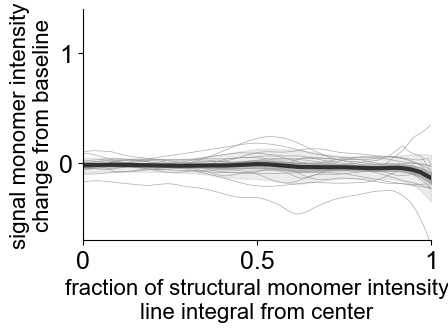

In [ ]:
file_path = r"screen 1"
fig_4_intensities = allinfunction(file_path)
average, stderr, std = calculate_plot_parameter(fig_4_intensities)
plot_4 (fig_4_intensities, average, stderr, std)

# linker12-[1-80aa]-C


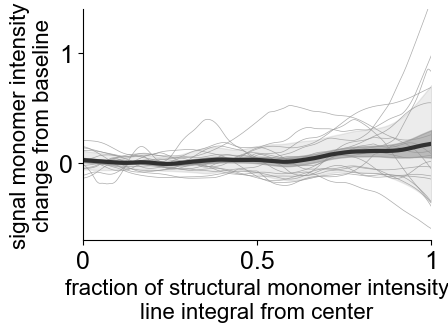

In [ ]:
file_path = r"screen 2"
fig_4_intensities = allinfunction(file_path)
average, stderr, std = calculate_plot_parameter(fig_4_intensities)
plot_4 (fig_4_intensities, average, stderr, std)

# (no linker)-[1-80aa]-C


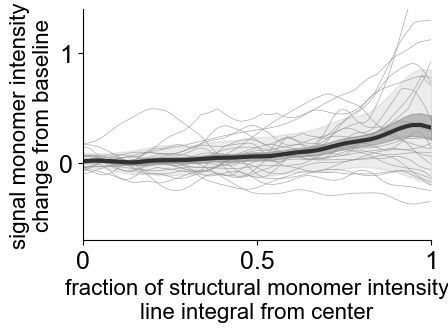

In [ ]:
file_path = r"screen 3"
fig_4_intensities = allinfunction(file_path)
average, stderr, std = calculate_plot_parameter(fig_4_intensities)
plot_4 (fig_4_intensities, average, stderr, std)

# linker2-[1-80aa]-C


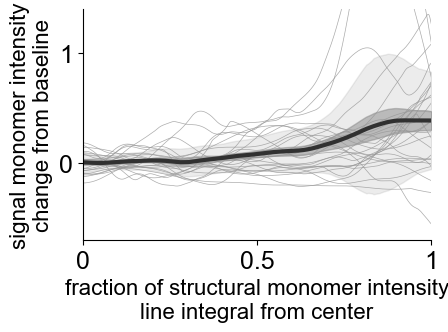

In [ ]:
file_path = r"screen 4"
fig_4_intensities = allinfunction(file_path)
average, stderr, std = calculate_plot_parameter(fig_4_intensities)
plot_4 (fig_4_intensities, average, stderr, std)

# linker6-[1-80aa]-C

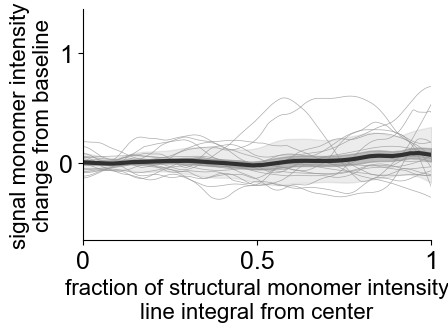

In [ ]:
file_path = r"screen 5"
fig_4_intensities = allinfunction(file_path)
average, stderr, std = calculate_plot_parameter(fig_4_intensities)
plot_4 (fig_4_intensities, average, stderr, std)

# linker24-[1-80aa]-C


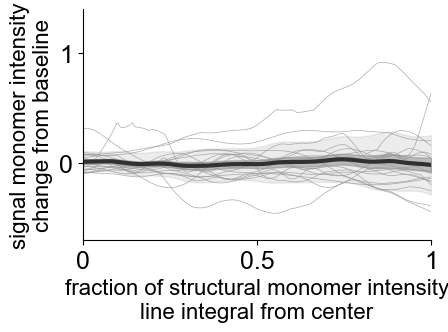

In [ ]:
file_path = r"screen 6"
fig_4_intensities = allinfunction(file_path)
average, stderr, std = calculate_plot_parameter(fig_4_intensities)
plot_4 (fig_4_intensities, average, stderr, std)

# linker2-NLS-[1-80aa]-C


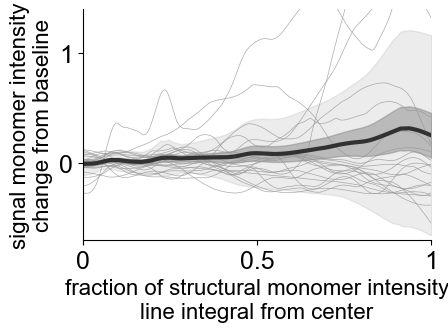

In [ ]:
file_path = r"screen 7"
fig_4_intensities = allinfunction(file_path)
average, stderr, std = calculate_plot_parameter(fig_4_intensities)
plot_4 (fig_4_intensities, average, stderr, std)

# [-MBP]-linker2- [1-80aa]-C


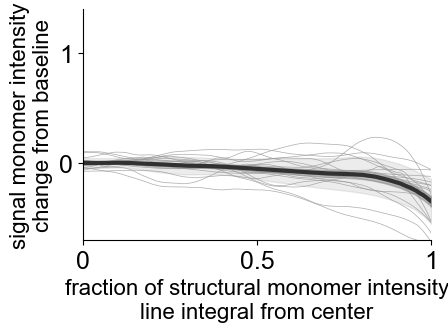

In [ ]:
file_path = r"screen 8"
fig_4_intensities = allinfunction(file_path)
average, stderr, std = calculate_plot_parameter(fig_4_intensities)
plot_4 (fig_4_intensities, average, stderr, std)